# Model Training

Trains **RandomForest** (baseline) and **XGBoost** (final) on `features.csv`.

> **Note on ground truth:** Priority labels are synthesised from CVSS + EPSS + `severity_score` since DefectDojo does not yet carry a labelled priority field.

**Outputs**
| File | Description |
|------|-------------|
| `data/model.pkl` | Fitted XGBoost pipeline (production model) |
| `data/rf_model.pkl` | Fitted RandomForest pipeline (baseline) |
| `data/model_metadata.json` | Feature list, label encoding, eval metrics |

## 0. Imports & Config

In [1]:
import json
import os
import warnings

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# --- Paths ---
INPUT_PATH = "data/features.csv"
XGB_OUT    = "data/model.pkl"
RF_OUT     = "data/rf_model.pkl"
META_OUT   = "data/model_metadata.json"

RANDOM_STATE = 42

## 1. Load Data

In [2]:
print(f"Loading {INPUT_PATH}...")
df = pd.read_csv(INPUT_PATH)
print(f"  Shape: {df.shape}")

df.head()

Loading data/features.csv...
  Shape: (460, 24)


,finding_id,title,severity,cvss_score,epss_score,epss_percentile,severity_score,age_days,is_verified,is_active,...,cwe_access_control,cwe_auth,cwe_config,cwe_crypto,cwe_data_exposure,cwe_injection,cwe_input_validation,cwe_memory,cwe_other,cwe_resource_mgmt
0,1640,javascript.sequelize.security.audit.sequelize-...,high,7.5,0.0,0.0,3,12,0,1,...,0,0,0,0,0,1,0,0,0,0
1,1641,javascript.sequelize.security.audit.sequelize-...,high,7.5,0.0,0.0,3,12,0,1,...,0,0,0,0,0,1,0,0,0,0
2,1642,javascript.audit.detect-replaceall-sanitizatio...,low,2.5,0.0,0.0,1,12,0,1,...,0,0,0,0,0,1,0,0,0,0
3,1643,javascript.sequelize.security.audit.sequelize-...,high,7.5,0.0,0.0,3,12,0,1,...,0,0,0,0,0,1,0,0,0,0
4,1644,javascript.sequelize.security.audit.sequelize-...,high,7.5,0.0,0.0,3,12,0,1,...,0,0,0,0,0,1,0,0,0,0


## 2. Synthetic Ground-Truth Labels

Priority is an integer class **0–3** (Low / Medium / High / Critical), derived by combining three risk signals:

$$
\text{raw\_priority} = 0.50 \times \text{cvss\_norm} + 0.30 \times \text{epss\_norm} + 0.20 \times \text{sev\_norm}
$$

The continuous score is then discretised into 4 buckets by **percentile** so every class is represented even in small datasets.

In [3]:
cvss_norm = df["cvss_score"].clip(0, 10) / 10.0
epss_norm = df["epss_score"].clip(0, 1)
sev_norm  = df["severity_score"].clip(0, 4) / 4.0

raw_priority = (
    0.50 * cvss_norm
    + 0.30 * epss_norm
    + 0.20 * sev_norm
)

# Percentile-based cuts → balanced-ish classes
p33 = np.percentile(raw_priority, 33)
p66 = np.percentile(raw_priority, 66)
p85 = np.percentile(raw_priority, 85)

print(f"Percentile thresholds — p33: {p33:.4f}  p66: {p66:.4f}  p85: {p85:.4f}")

Percentile thresholds — p33: 0.3500  p66: 0.5250  p85: 0.5404


In [4]:
def assign_label(v):
    if v >= p85: return 3   # Critical
    if v >= p66: return 2   # High
    if v >= p33: return 1   # Medium
    return 0                # Low

df["priority"] = raw_priority.apply(assign_label)

label_names = {0: "Low", 1: "Medium", 2: "High", 3: "Critical"}

dist = pd.DataFrame([
    {"Class": label_names[k], "Count": (df["priority"] == k).sum(),
     "Pct": f"{100*(df['priority']==k).mean():.1f}%"}
    for k in range(4)
])
print("Priority distribution:")
dist

Priority distribution:


,Class,Count,Pct
0,Low,115,25.0%
1,Medium,182,39.6%
2,High,92,20.0%
3,Critical,71,15.4%


## 3. Feature Selection

Drop non-numeric, identifier, and **leaking** columns (`ai_risk_score` and `ai_severity` are derived from the same CVSS/EPSS signals and would trivially reveal the label).

In [5]:
DROP_COLS = [
    "finding_id", "title",
    "severity",       # text; severity_score encodes this numerically
    "ai_risk_score",  # derived from same signals → leakage
    "ai_severity",    # ditto
    "priority",       # the label itself
]

feature_cols = [
    c for c in df.columns
    if c not in DROP_COLS and df[c].dtype != object
]

print(f"Features selected ({len(feature_cols)}):")
print(feature_cols)

X = df[feature_cols].fillna(0).astype(float).values
y = df["priority"].values

print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")

Features selected (19):
['cvss_score', 'epss_score', 'epss_percentile', 'severity_score', 'age_days', 'is_verified', 'is_active', 'has_cve', 'scanner_OTHER', 'cwe_access_control', 'cwe_auth', 'cwe_config', 'cwe_crypto', 'cwe_data_exposure', 'cwe_injection', 'cwe_input_validation', 'cwe_memory', 'cwe_other', 'cwe_resource_mgmt']

X shape: (460, 19)  |  y shape: (460,)


## 4. Build Pipelines

In [6]:
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )),
])

print("Pipelines ready.")

Pipelines ready.


## 5. Cross-Validation (5-Fold Stratified)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Cross-validating RandomForest...")
rf_scores = cross_val_score(rf_pipe, X, y, cv=cv, scoring="f1_weighted", n_jobs=-1)
print(f"  F1-weighted (5-fold): {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

print("\nCross-validating XGBoost...")
xgb_scores = cross_val_score(xgb_pipe, X, y, cv=cv, scoring="f1_weighted", n_jobs=-1)
print(f"  F1-weighted (5-fold): {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")

Cross-validating RandomForest...
  F1-weighted (5-fold): 0.9957 ± 0.0053

Cross-validating XGBoost...
  F1-weighted (5-fold): 0.9935 ± 0.0053


In [8]:
cv_summary = pd.DataFrame({
    "Model":    ["RandomForest", "XGBoost"],
    "CV F1 Mean": [rf_scores.mean(), xgb_scores.mean()],
    "CV F1 Std":  [rf_scores.std(),  xgb_scores.std()],
})
cv_summary.style.format({"CV F1 Mean": "{:.4f}", "CV F1 Std": "{:.4f}"})

,Model,CV F1 Mean,CV F1 Std
0,RandomForest,0.9957,0.0053
1,XGBoost,0.9935,0.0053


## 6. Final Fit on Full Dataset

In [9]:
print("Fitting final models on full dataset...")
rf_pipe.fit(X, y)
xgb_pipe.fit(X, y)
print("Done.")

Fitting final models on full dataset...
Done.


### In-Sample Metrics  *(informational only — not a substitute for CV)*

In [10]:
rf_pred  = rf_pipe.predict(X)
xgb_pred = xgb_pipe.predict(X)

rf_f1  = f1_score(y, rf_pred,  average="weighted")
xgb_f1 = f1_score(y, xgb_pred, average="weighted")

print(f"RF  in-sample F1 (weighted): {rf_f1:.4f}")
print(f"XGB in-sample F1 (weighted): {xgb_f1:.4f}")

# One-vs-rest AUC
try:
    rf_proba  = rf_pipe.predict_proba(X)
    xgb_proba = xgb_pipe.predict_proba(X)
    rf_auc  = roc_auc_score(y, rf_proba,  multi_class="ovr", average="weighted")
    xgb_auc = roc_auc_score(y, xgb_proba, multi_class="ovr", average="weighted")
    print(f"RF  OvR AUC: {rf_auc:.4f}")
    print(f"XGB OvR AUC: {xgb_auc:.4f}")
except Exception as e:
    rf_auc = xgb_auc = None
    print(f"AUC calculation skipped: {e}")

RF  in-sample F1 (weighted): 0.9978
XGB in-sample F1 (weighted): 1.0000
RF  OvR AUC: 1.0000
XGB OvR AUC: 1.0000


### XGBoost Classification Report

In [11]:
print(classification_report(
    y, xgb_pred,
    target_names=[label_names[i] for i in range(4)]
))

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       115
      Medium       1.00      1.00      1.00       182
        High       1.00      1.00      1.00        92
    Critical       1.00      1.00      1.00        71

    accuracy                           1.00       460
   macro avg       1.00      1.00      1.00       460
weighted avg       1.00      1.00      1.00       460



### Confusion Matrix — XGBoost

In [12]:
cm = confusion_matrix(y, xgb_pred)
cm_df = pd.DataFrame(
    cm,
    index   = [f"True {label_names[i]}"    for i in range(4)],
    columns = [f"Pred {label_names[i]}" for i in range(4)],
)
cm_df

,Pred Low,Pred Medium,Pred High,Pred Critical
True Low,115,0,0,0
True Medium,0,182,0,0
True High,0,0,92,0
True Critical,0,0,0,71


### Feature Importances — XGBoost

In [13]:
importances = xgb_pipe.named_steps["clf"].feature_importances_
fi = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)

fi_df = pd.DataFrame(fi, columns=["Feature", "Importance"])
print("Top 10 feature importances (XGBoost):")
fi_df.head(10)

Top 10 feature importances (XGBoost):


,Feature,Importance
0,severity_score,0.244058
1,cvss_score,0.157173
2,is_active,0.113618
3,cwe_memory,0.088015
4,cwe_crypto,0.075922
5,cwe_auth,0.071509
6,cwe_other,0.061162
7,cwe_data_exposure,0.050432
8,epss_score,0.040614
9,epss_percentile,0.024784


<Axes: title={'center': 'Top 10 XGBoost Feature Importances'}, xlabel='Importance', ylabel='Feature'>

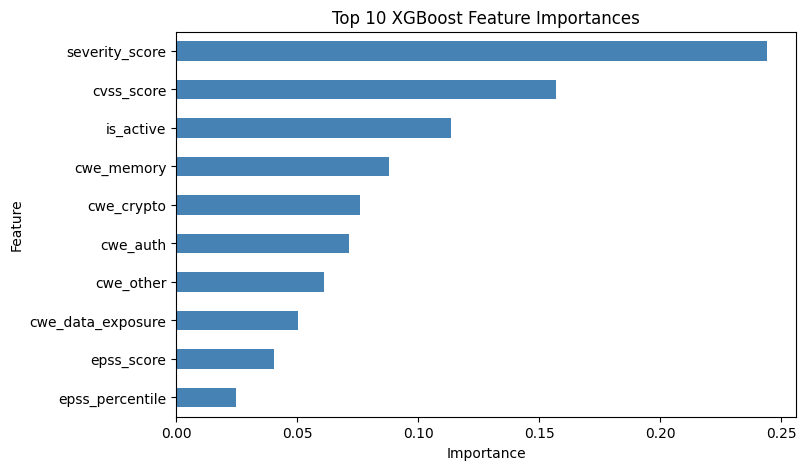

In [14]:
fi_df.head(10).set_index("Feature")["Importance"].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 XGBoost Feature Importances",
    xlabel="Importance",
    color="steelblue",
)

## 7. Save Models & Metadata

In [15]:
os.makedirs("data", exist_ok=True)

joblib.dump(xgb_pipe, XGB_OUT)
joblib.dump(rf_pipe,  RF_OUT)
print(f"Saved XGBoost model → {XGB_OUT}")
print(f"Saved RandomForest  → {RF_OUT}")

metadata = {
    "trained_at":       pd.Timestamp.utcnow().isoformat() + "Z",
    "n_samples":        int(len(df)),
    "feature_columns":  feature_cols,
    "label_encoding":   label_names,
    "label_thresholds": {
        "p33": float(p33),
        "p66": float(p66),
        "p85": float(p85),
    },
    "cv_folds": 5,
    "rf": {
        "cv_f1_mean":   float(rf_scores.mean()),
        "cv_f1_std":    float(rf_scores.std()),
        "insample_f1":  float(rf_f1),
        "insample_auc": float(rf_auc) if rf_auc else None,
    },
    "xgb": {
        "cv_f1_mean":   float(xgb_scores.mean()),
        "cv_f1_std":    float(xgb_scores.std()),
        "insample_f1":  float(xgb_f1),
        "insample_auc": float(xgb_auc) if xgb_auc else None,
    },
    "feature_importances": {f: float(i) for f, i in fi},
}

with open(META_OUT, "w") as fh:
    json.dump(metadata, fh, indent=2)

print(f"Saved metadata      → {META_OUT}")
print("\nPhase 2 complete.")

Saved XGBoost model → data/model.pkl
Saved RandomForest  → data/rf_model.pkl
Saved metadata      → data/model_metadata.json

Phase 2 complete.
